# Transit Photometry Workbook
This workbook will guide you through photometry of the star Wasp-2 in order to produce a transit lightcurve and measure the basic properties of the exoplanet Wasp-2 b.

### Imports
These packages include functions that will do most of the more tedious work for us, such as creating photometric apertures. The next cell includes all imports.

In [1]:
import numpy as np
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.time import Time
from scipy.optimize import least_squares
from datetime import datetime

from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.centroids import centroid_2dg
from photutils.centroids import centroid_sources

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from sow_tools import mask_bad_pix

The below cell is the base path where all the files for this project are located. Do not edit.

In [2]:
store_path = 'raw/'

We need to get the names of all the files we will be using. Edit the list definitions below with correct file names and locations.
e.g. bias_files = ['file1.fits', 'file2.fits', etc...]. Find the correct files to use in the observing log from June 19th 2022, available as a .pdf in this assignment folder. 

https://jupyter1.idre.ucla.edu/services/phys180s22/files/phys180s22/source/Wasp-2b%20Transit%20Analysis/Observing%20Log.xlsx%20-%2020220619.pdf

In [3]:
bias_files = [store_path+f'd10{i:02}.fits' for i in range(22,31,1)]
flat_files = [store_path+f'd10{i:02}.fits' for i in range(0,22,1)]
sci_files = [store_path+f'd1{i:03}.fits' for i in range(75,155,1)]

### Creating main calibrations
We want to average our individual calibration images together to make a main image that is more accurate than any of the individual images. To do this, we will read in the image data from each of our individual calibrations then take the median of every pixel value. It is better to take the median instead of a true average because the median is not changed by one large outlier, while an average is.

### Edit the code below to create a main bias image and save it in the main_bias variable
Reference the data reduction workbook or ask an instructor for help if you aren't sure what to do.

In [4]:
main_bias = fits.getdata(bias_files[8])

We will now plot the main bias to see what it looks like, no editing required.

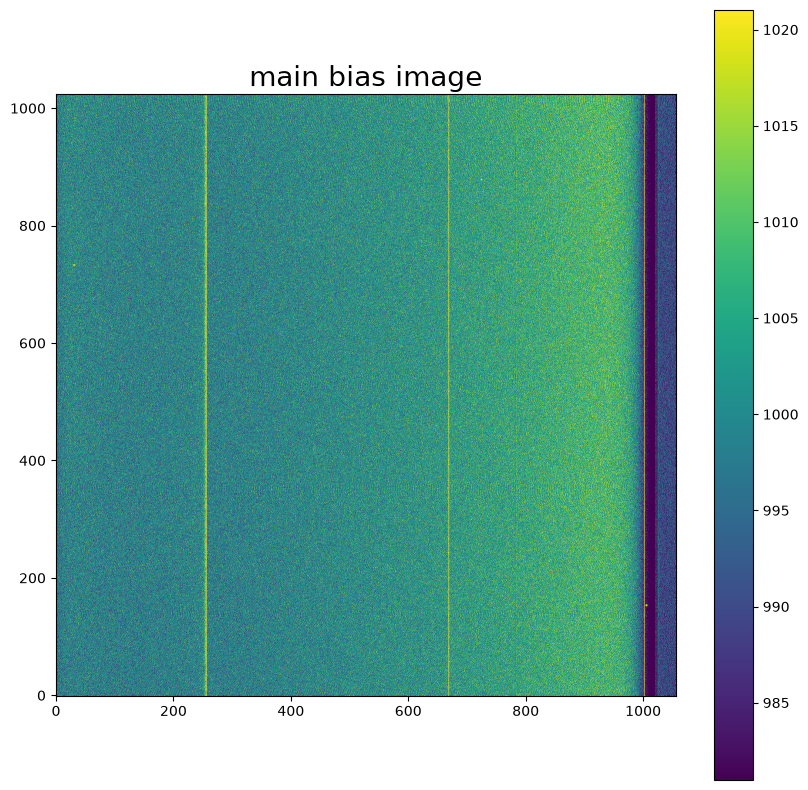

In [ ]:
%matplotlib widget

med_bval = np.nanmedian(main_bias)

plt.figure(figsize=(10,10))
plt.imshow(main_bias, vmin=med_bval*0.98, vmax=med_bval*1.02, origin='lower')
plt.colorbar()
plt.title('main bias image', fontsize=20)
plt.show()

Now do the same but for the flat images. Save the image in the main_flat variable.
Remember that each individual flat image needs the main_bias subtracted from it before they are combined together.

In [6]:
main_flat = fits.getdata(flat_files[8])

Once again we will plot the main flat to see what it looks like:

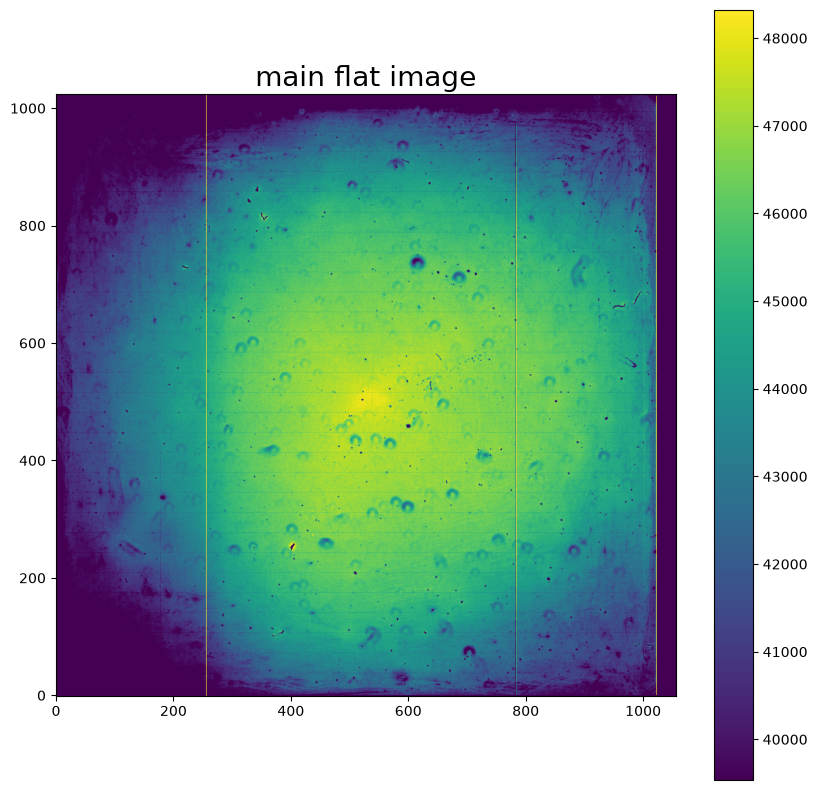

In [ ]:
med_fval = np.nanmedian(main_flat)

plt.figure(figsize=(10,10))
plt.imshow(main_flat, vmin=med_fval*0.9, vmax=med_fval*1.1, origin='lower')
plt.colorbar()
plt.title('main flat image', fontsize=20)
plt.show()

### Correcting our science images with the main calibrations
Here we will use our main bias and main flat images to correct all of the science images. The science images are loaded for you, but you need to input the math for correcting them into the loop. 

In addition, we will use a function **mask_bad_pix** to remove bax pixels and cosmic rays from our science images. This function is already written, you simply need to give it the corrected image as the **sci_im** variable.
At the end of this cell, we save important information from the .fits header, specifically the time that the observations occurred.

In [8]:
num_sci = len(sci_files)
sci_data = np.empty((num_sci,1024,1024))
time_data = []
for i, file in enumerate(sci_files):
    # loop through all science files
    hdu = fits.open(file)
    
    sci_im = fits.getdata(file)
    
    # mask_bad_pix will search for significant outliers in our data and remove them, we also remove an unneeded overscan region of the images
    sci_data[i] = mask_bad_pix(sci_im)[0:1024,0:1024] #NOTE Changed sow_tools to get rid of float nan to integer conversion issue
    
    # write the corrected science files into new .fits files that will be saved
    tmp = fits.PrimaryHDU(sci_data[i], header=hdu[0].header)
    tmpl = fits.HDUList(tmp)
    tmpl.writeto(file.strip('.fits')+'_calib.fits', overwrite=True)
    tmpl.close()
    
    # get the beginning and end time of each exposure
    time_data.append([Time(hdu[0].header['DATE-BEG'], format='isot', scale='utc'), Time(hdu[0].header['DATE-END'], format='isot', scale='utc')]) 
    
    # close and go to the next image
    hdu.close()


Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...

Marking bad pixels (may take several minutes)...


### Marking the target star and comparison stars
To perform photometry of Wasp-2, we need to identify its pixel location within the image. We also need to identify the pixel locations of at least 5 comparison stars within the image that we will also perform photometry on. The photometry from the comparison stars, which presumably do not have any transits occuring, will be used to correct out any non-transit features from our target lightcurve.

In the next cell, we plot one of the science images. Below that, you need to edit the **star_dict** dictionary to contain the positions of the target and at least 5 other comparison stars.

Use the finding chart included with this assignment to identify which star is Wasp-2.

https://jupyter1.idre.ucla.edu/services/phys180s22/view/phys180s22/source/Wasp-2b%20Transit%20Analysis/wasp2_chart.PNG

In [9]:
print(sci_files[75])

raw/d1150.fits


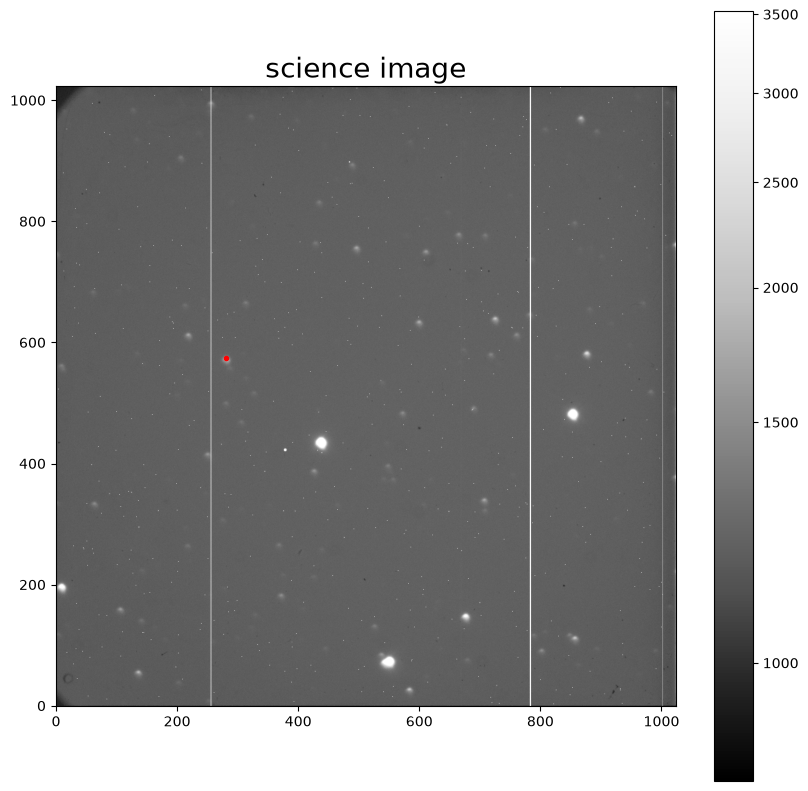

In [ ]:
med_sval = np.nanmedian(sci_data[75])

plt.figure(figsize=(10,10))
norm = ImageNormalize(stretch=SqrtStretch(),vmin=med_sval*0.8, vmax=med_sval*3) #NOTE changed vmin and max to here
plt.imshow(sci_data[75], origin='lower', cmap='Greys_r', norm=norm) #NOTE from here
plt.colorbar()
plt.plot(280,575,'r.')
plt.title('science image', fontsize=20)
plt.show()

In [11]:
star_dict = {'target':[438,435],
            'c1':[549,72],
            'c2':[676,148],
            'c3':[854,481],
            'c4':[280,575], #NOTE Removed object c5 because there aren't enough good stars in the photo
            }

Now we will refine the centroid positions of the stars using the phoutils package and plot an circular aperture over each one. Make sure that the stars you intended to select have apertures over them! If they do, no action is needed.

target
c1
c2
c3
c4


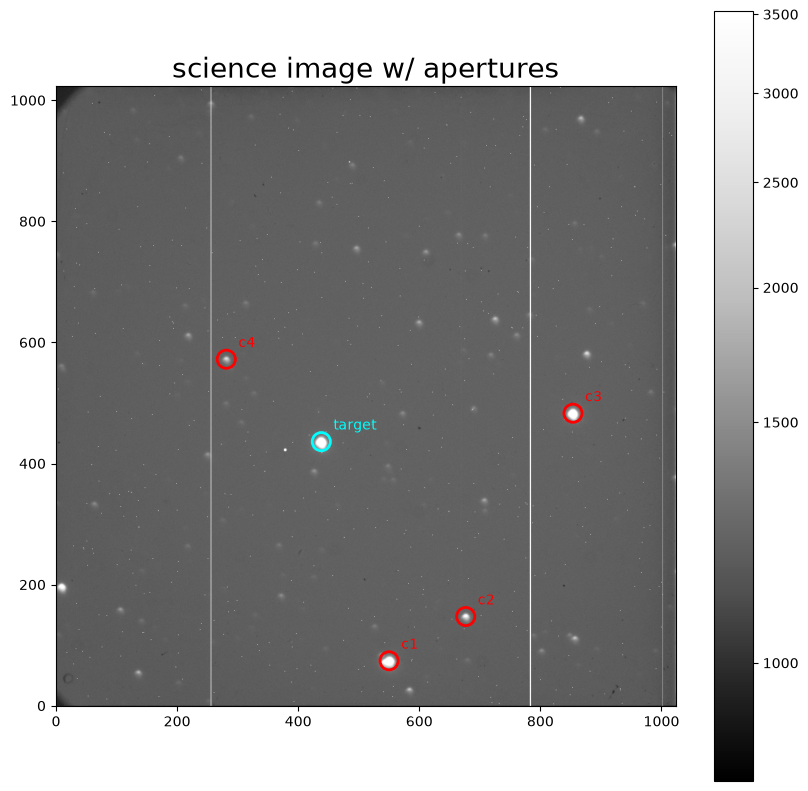

In [12]:
# %matplotlib widget #NOTE changed

med_sval = np.nanmedian(sci_data[75])

plt.figure(figsize=(10,10))
norm = ImageNormalize(stretch=SqrtStretch(), vmin=med_sval*0.8, vmax=med_sval*3) #NOTE Same vas two cells above
plt.imshow(sci_data[75], origin='lower', cmap='Greys_r', norm=norm)

for key in star_dict.keys():
    print(key)
    x, y = centroid_sources(sci_data[75], star_dict[key][0], star_dict[key][1], box_size=21,
                        centroid_func=centroid_2dg)
    pos = (x[0],y[0])
    star_dict[key] = pos
    ap = CircularAperture(pos,r=15)
    if key == 'target':
        ap.plot(color='cyan', lw=2,
                label='Photometry aperture')
        plt.text(x[0]+20,y[0]+20, key, color='cyan') #NOTE We added [0] to x and y
    else:
        ap.plot(color='red', lw=2,
                label='Photometry aperture')
        plt.text(x[0]+20,y[0]+20, key, color='red') #NOTE We added [0] to x and y
    
plt.colorbar()
plt.title('science image w/ apertures', fontsize=20)
plt.show()    

### Lightcurve photometry
Now we have our target and comparison stars selected, its time to loop through all of our science images and actually do the photometry. 

In the next cell, we will define the aperture and sky annulus sizes we want to use. You should decide what sizes to use based on the aperture plot that the cell will produce. Make your best guess for good values to start, but you may want to experiment with different sizes after you produce the lightcurve to see what values produce the clearest transit in the final lightcurve.

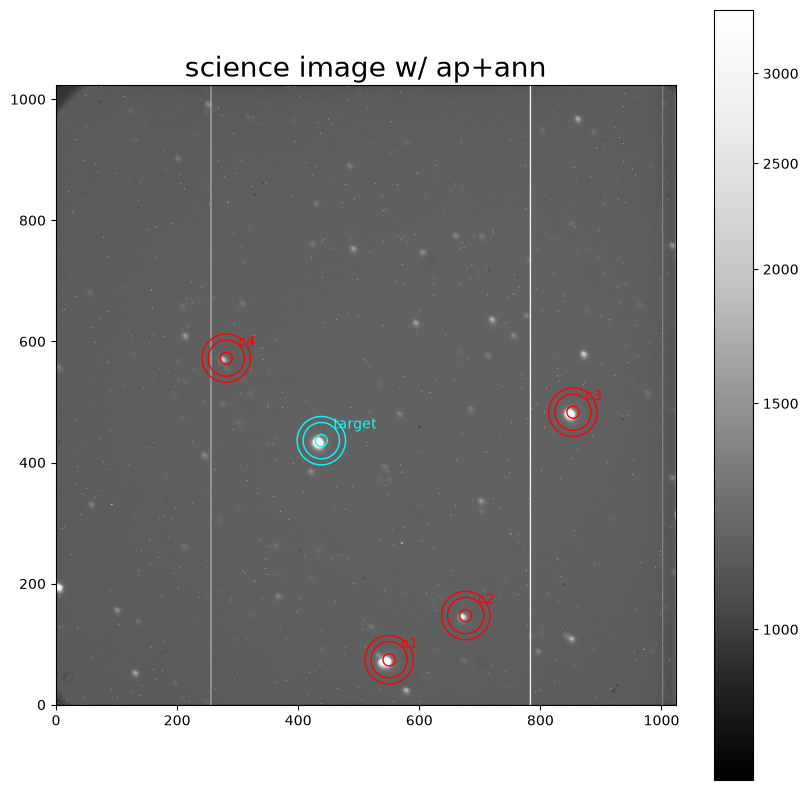

In [13]:
ap_radius = 10
ann_rad_in = 30
ann_rad_out = 40

# %matplotlib widget #NOTE changed

med_sval = np.nanmedian(sci_data[0])

plt.figure(figsize=(10,10))
norm = ImageNormalize(stretch=SqrtStretch(),vmin=med_sval*0.8, vmax=med_sval*3,) #NOTE Changed
plt.imshow(sci_data[0], origin='lower', cmap='Greys_r', norm=norm) #NOTE Changed

for key in star_dict.keys():
    pos = star_dict[key]
    x, y = pos[0], pos[1]
    ap = CircularAperture(pos,r=ap_radius)
    ann = CircularAnnulus(pos,r_in=ann_rad_in, r_out=ann_rad_out)
    if key == 'target':
        ap.plot(color='cyan', lw=1,
                label='Photometry aperture')
        ann.plot(color='cyan', lw=1,
                label='Photometry aperture')
        plt.text(x+20,y+20, key, color='cyan')
    else:
        ap.plot(color='red', lw=1,
                label='Photometry aperture')
        ann.plot(color='red', lw=1,
                label='Photometry aperture')
        plt.text(x+20,y+20, key, color='red')
    
plt.colorbar()
plt.title('science image w/ ap+ann', fontsize=20)
plt.show()   

Now we will loop through our science images and get photometry.

In [ ]:
snum = len(sci_data)
phot_dict = {'target':np.empty(snum),
            'c1':np.empty(snum),
            'c2':np.empty(snum),
            'c3':np.empty(snum),
            'c4':np.empty(snum), #NOTE Removed object c5 because there aren't enough good stars in the photo
            }


for i, data in enumerate(sci_data): 
    for key in phot_dict.keys():
        # refine centroid
        print(key)
        print(star_dict[key][0],star_dict[key][1])
        x, y = centroid_sources(data, star_dict[key][0], star_dict[key][1], box_size=21,
                            centroid_func=centroid_2dg)
        pos = (x[0],y[0])
        star_dict[key] = pos
        
        # mask bad pixel locations
        mask = np.ma.masked_invalid(data).mask
        
        ap = CircularAperture(pos,r=ap_radius)
        ann = CircularAnnulus(pos,r_in=ann_rad_in, r_out=ann_rad_out)
        
        ap_sum = aperture_photometry(data, ap, mask=mask)['aperture_sum']
        ann_sum = aperture_photometry(data,ann,mask=mask)['aperture_sum']
        
        bkg_mean = ann_sum / ann.area
        phot = ap_sum - (bkg_mean*ap.area)  
        phot_dict[key][i] = phot.value[0] #NOTE Changed from phot to phot.value[0] as it was a series object
    

target
438.1684106198308 436.130548338798
c1
550.0380051781484 74.18336428756237
c2
676.681219567328 147.2608827094609
c3
853.7865105999666 483.04447567438746
c4
281.20671416086276 572.2520379231353
target
433.01559192870855 433.7433367096951
c1
545.2375214653805 72.01553606783175
c2
667.0711197635853 144.64347023456676
c3
848.5785416771809 480.6569694679356
c4
275.1894217870767 569.5738150694423
target
432.6997526020963 434.24776590530894
c1
544.3916521322642 72.39795605009508
c2
671.0787333385173 145.24301691036277
c3
848.2052912989811 481.1589125246749
c4
275.78376507765256 569.9591903883849
target
432.4755711561268 434.23705714905486
c1
544.165061120166 72.34525603608937
c2
670.98840731916 145.18940318822737
c3
847.9443484735668 481.1849217041019
c4
276.0040658299683 569.9384393561458
target
434.03748896197067 434.267801717508
c1
545.8012110292525 72.35920762046763
c2
672.2135865359551 145.17108104662105
c3
849.5653116185719 481.15398631279595
c4
277.1355583726332 569.9473063770369

target
434.07109015871265 434.94815529122656
c1
545.8981963077166 73.04056907451817
c2
672.7898266423022 145.9116637334551
c3
849.6577800584935 481.9009133651386
c4
277.7543695151136 570.7154255171681
target
434.87859483096986 434.7870783474662
c1
546.6454003975598 72.833369940414
c2
673.4041590928854 145.81730672685498
c3
850.4988846206859 481.70473430258176
c4
278.2187252317389 570.6046860600181
target
434.9271327375992 434.6416965860943
c1
546.6041584781891 72.69034537654122
c2
673.3464865815797 145.69147241868433
c3
850.4532374814263 481.55818589315885
c4
278.23255384433037 570.4823987094765
target
434.4874034948013 434.5812323627277
c1
546.3656775843825 72.69045021646538
c2
673.1016339658884 145.71834143790102
c3
850.0927692894087 481.51420828288434
c4
277.98823134407905 570.1469132348863
target
435.33790374263754 435.0346338421932
c1
547.1051290394912 73.07563145605835
c2
673.7313673252938 145.97659942894325
c3
850.9686152221363 481.9027985941036
c4
278.5258655294701 570.42053971

c4
278.56215667165844 570.373864315881
target
435.09374092629764 435.04898199180917
c1
546.9282146467602 73.14611869909761
c2
673.8341668176304 145.98037121910843
c3
850.7473398206407 481.9715848179686
c4
278.7828066542619 570.4514737396648
target
435.5625577404749 434.9082784740203
c1
547.3052161986011 72.9587580962776
c2
674.1249894446262 145.91237615079262
c3
851.1329807568344 481.8180688705344
c4
279.0194625572116 570.3858777423942
target
435.4026975309172 434.7800015969954
c1
547.1582051474145 72.81415498691099
c2
674.0704307444162 145.7916027135988
c3
851.0585500548309 481.6667340671316
c4
278.90628669569503 570.2808508435738
target
435.00116222968256 435.2370967333528
c1
546.8429537543833 73.28785193746984
c2
673.737314148516 146.07000723944466
c3
850.588060361758 482.1445120526858
c4
278.63971647718006 570.57878982676
target
435.90049448996695 434.80168260897807
c1
547.6607721159536 72.84817337729727
c2
674.3806634226175 145.77023199630622
c3
851.5155457050462 481.7108346761193

c2
674.814840729075 146.0213679984969
c3
851.6372691669208 482.0561301841763
c4
279.7040144589805 570.8517302401982
target
436.0844789741897 435.12808854173807
c1
547.9078931725372 73.17876143331446
c2
674.8492258770327 145.98614308425962
c3
851.7134346248185 482.05019825441843
c4
279.73095681227437 570.7850060444833
target
436.29771522358067 434.9305420105431
c1
548.0604484370723 72.98687069400587
c2
674.9271602761195 145.8687998623466
c3
851.870236446826 481.8377460792881
c4
279.7855393022112 570.6994928756201
target
436.7252078046592 435.2213641818503
c1
548.4958137278602 73.25016847612338
c2
675.2830954262633 145.99527236905038
c3
852.2612893951404 482.10489829703573
c4
280.114721953551 570.8332002782561
target
436.40600234884283 435.3694830744118
c1
548.2539977043245 73.4242903216861
c2
675.0697438352431 146.1007988561991
c3
851.9732568458336 482.2784573478981
c4
279.9405901434697 570.887667948217
target
436.40563723713177 434.70005701641736
c1
548.2160640196848 72.75041631055308


c2
676.279095115652 146.1155530661784
c3
853.3093472725551 482.2616570322088
c4
281.1440225048809 570.8882285361872
target
437.57350897496343 435.66064491035024
c1
549.4463936569089 73.68536897938142
c2
676.2140790091754 146.27205949647677
c3
853.1625782479704 482.59109407311473
c4
280.98780959749223 571.0175782455445
target
437.3128595750151 435.7877147450986
c1
549.1821246476229 73.8505712965834
c2
676.009064680595 146.40669253249797
c3
852.9007222226179 482.7162285870682
c4
280.8285751795585 571.1675430013993
target
437.8223401332185 435.87595592546614
c1
549.6494021843178 73.93811256537066
c2
676.3906337154231 146.4740190681631
c3
853.4248077097537 482.79779294453596
c4
281.18006445230833 571.2027457447884
target
437.5097489895409 435.9860100819823
c1
549.3851744014715 74.06290541751738
c2
676.1512263869905 146.59459548130963
c3
853.1302291135958 482.9170210663458
c4
280.9502014280694 571.2774405246289
target
438.08035536986006 435.8269813828671
c1
549.8867358768389 73.875342670961

c1
549.9881473527215 73.98525914462729
c2
676.8825087792626 146.77544433124302
c3
853.7248649615902 482.8610251279441
c4
281.73413880208574 571.2294961213103
target
438.71186256126265 435.8884154140888
c1
550.5579611115062 73.98032993749837
c2
677.345088254921 146.8420449133379
c3
854.3689256653274 482.83406015464305
c4
282.0780162193241 571.2845439360309
target
438.672740500638 436.0108871441795
c1
550.5863573224983 74.06958097632169
c2
677.2886752999766 146.89805707467585
c3
854.245567005773 482.9120367771432
c4
282.0498973600964 571.3751005578645
DONE


### Looking at the raw lightcurves
Why we use comparison stars becomes clear if we now plot the photometry of all our comparison stars together. You should see that all the stars have photometry the follows the same rough trend, but no transit is obviously visible in the target photometry.

The cell below plots the raw lightcurves with offsets in flux so that the lightcurves are not displayed on top of each other.

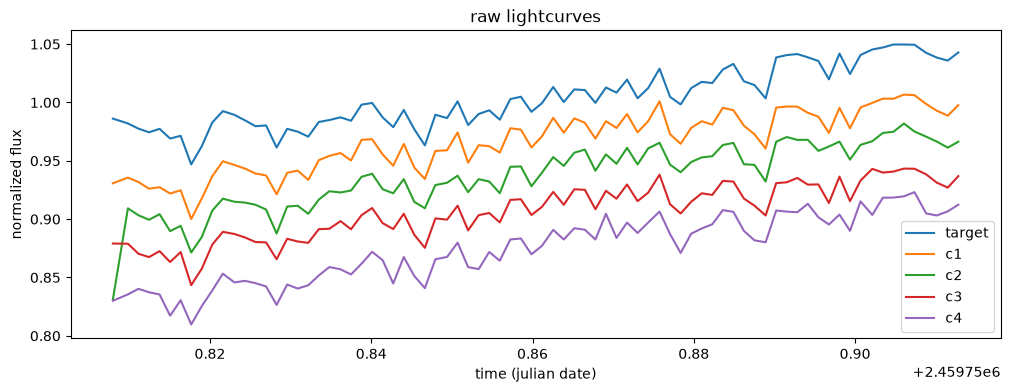

In [ ]:
# get time of all observations
t = np.empty(len(time_data))
for i in range(len(time_data)):
    tstart = time_data[i][0]
    tend = time_data[i][1]
    t[i] = (((tend-tstart)/2) + tstart).jd

# plot raw lightcurves
plt.figure(figsize=(12,4))
sep = 0
for key in phot_dict.keys():
    plt.plot(t, phot_dict[key]/np.nanmedian(phot_dict[key]) - sep, label=key)
    sep += 0.03 # creates offset between lightcurves so they don't stack on top of each other
    
plt.ylabel('normalized flux')
plt.xlabel('time (julian date)')
plt.legend()
plt.title('raw lightcurves')
plt.show()

### Detrending our lightcurve!

Let's use the comparison lightcurves we plotted above to remove the "trends" in our target lightcurve and reveal the transit. Take a median of the comparison star photometry for every point in time, and divide that median from the target photometry at that time. Save the "detrended" lightcurve in the **detrended** variable. We will then plot the detrended lightcurve below, and you should see a clear transit.

If you do not see a transit, check if any mistakes may have been made on this or previous steps, and ask the instructor for help!

In [16]:
empty = np.empty((4,len(phot_dict['c1'])))
for i,key in enumerate(phot_dict.keys()):
    if(i!=0):
        empty[i-1]=phot_dict[key]

In [17]:
detrended = phot_dict['target'] / np.nanmedian(empty,axis=0)
detrended = detrended[1:]
t = t[1:]

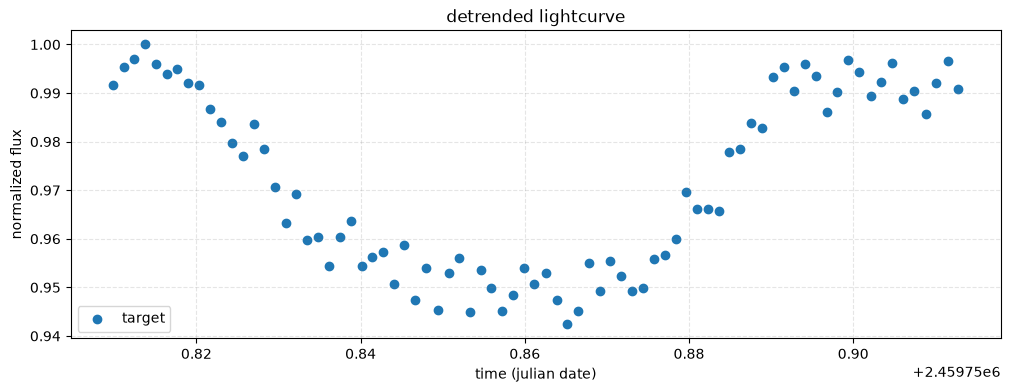

In [19]:

        
# plot raw lightcurves
# %matplotlib widget
plt.figure(figsize=(12,4))
plt.scatter(t, detrended-np.max(detrended)+1, label='target')
    
plt.ylabel('normalized flux')
plt.xlabel('time (julian date)')
plt.legend()
plt.title('detrended lightcurve')
# plt.axes().xaxis.set_minor_locator(AutoMinorLocator()) #NOTE This seems to be screwing up the plotting somehow
plt.grid(which='both', color='grey', linestyle='--', alpha=0.2) #NOTE removed b kwarg as it is no longer working
plt.show()

### Fitting a model to the transit

We see the transit, let's measure its duration and depth so we can understand what kind of planet we are dealing with (a giant planet like Jupiter, or a small planet like Earth). Below, we have written a function that will fit a transit model to the data. You just need to make some initial guesses on when the transit begins and ends. The units of time are in Julian Date (JD - https://en.wikipedia.org/wiki/Julian_day), which is an absolute date system where days have been counted sequentially since a zero point several thousand years ago. The JD of the transit is in the millions.

In [21]:
base_add = 2459750
time_ig_begin = base_add + 0.82
time_ig_end = base_add + 0.842
time_eg_begin = base_add + 0.875
time_eg_end = base_add + 0.89

In [22]:
# piecewise function that creates a trapezoidal transit shape
def transit_model(time, base, depth, t0, duration, ineg_duration):
    # outside transit
    if abs(time-t0)> duration/2+ineg_duration:
        flux = base
    # egress
    elif -(duration/2+ineg_duration)<t0-time<-duration/2:
        flux = base - depth + depth / ineg_duration * (time-(t0+duration/2))
    # ingress
    elif (duration/2+ineg_duration)>t0-time>duration/2:
        flux = base - depth / ineg_duration * (time-(t0-duration/2-ineg_duration))
    # in transit
    elif abs(time-t0)<duration/2:
        flux = base-depth
    
    return flux

In [23]:
# function the calculates difference between model and data
def residual(g):
    f = []
    for i in t:
        f.append(transit_model(i,base,depth,g[0],g[1],g[2]))

    res = np.sum((f-(detrended))**2)
    return res

In [ ]:
# depth is calculated based on the in transit and out of transit points
base = np.median(detrended[np.where((t<time_ig_begin)|(t>time_eg_end))]) # out of transit flux
it_base = np.median(detrended[np.where((t<time_eg_begin)&(t>time_ig_begin))]) # in transit flux
depth = base-it_base
# error in depth calculated as std error of the mean
depth_err = np.std(detrended[np.where((t<time_eg_begin)&(t>time_ig_begin))])*2**0.5 / len(detrended[np.where((t<time_eg_begin)&(t>time_ig_begin))])**0.5

# these arrays are the initial guesses and bounds for the model parameters
g0 = np.array([(time_eg_end-time_ig_end)/2 + time_ig_end,
               time_eg_end-time_ig_end,
               (time_eg_end-time_eg_begin + time_ig_end-time_ig_begin)/2])
gb = np.array([(time_ig_end,g0[1]/4,g0[2]/4),
               (time_eg_begin,g0[1]*2,g0[2]*2)])

# do the model fitting, may need to adjust diff_step if the guess is being given as the solution
fit = least_squares(residual, g0, bounds=gb, xtol=1e-14, verbose=2, diff_step=[1e-9,1e-3,1e-3])

base =  2.4487583705752627
[2.44704882 2.45081303 2.45234847 2.45536966 2.45125958 2.44930239
 2.45035185 2.44740753 2.44702949 2.44211512 2.43951506 2.43502625
 2.43237814 2.43900238 2.43381599 2.42597819 2.41862271 2.4246235
 2.41504423 2.41568914 2.40980053 2.41582405 2.41896768 2.40967638
 2.41158406 2.41266954 2.40615951 2.41412015 2.40271368 2.40936381
 2.40076675 2.40841045 2.41142179 2.40029594 2.40901347 2.40525672
 2.40040559 2.40386128 2.40944756 2.40606624 2.40824136 2.40283645
 2.39772961 2.40048224 2.41048956 2.40464442 2.41072861 2.40775791
 2.40461042 2.40531705]
in transit base =  2.4097384504685992
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.5281e-05                                    4.95e-04    
       1              2         1.3331e-05      7.20e-05       6.22e-03       9.28e-05    
       2              3         3.0297e-06      1.03e-05       4.08e-03       2.50e-05    
       3    

### Results
The next two boxes print the results of our fit, then displays the model compared to the data. Make sure the results make sense, otherwise you may need to change your guesses on the transit timing. 

In [26]:
print('transit midpoint:', fit.x[0], 'JD +/-', fit.jac[0][0])
print('duration:', (fit.x[1]+2*fit.x[2]) * 24, 'hours +/-', (fit.jac[0][1]) * 24)
print('depth:', depth*100, '% +/-', depth_err*100)

transit midpoint: 2459750.8549658414 JD +/- 0.02607836873076528
duration: 1.7516656281838974 hours +/- 1.1113269271181738
depth: 3.901992010666344 % +/- 0.27532153384123015


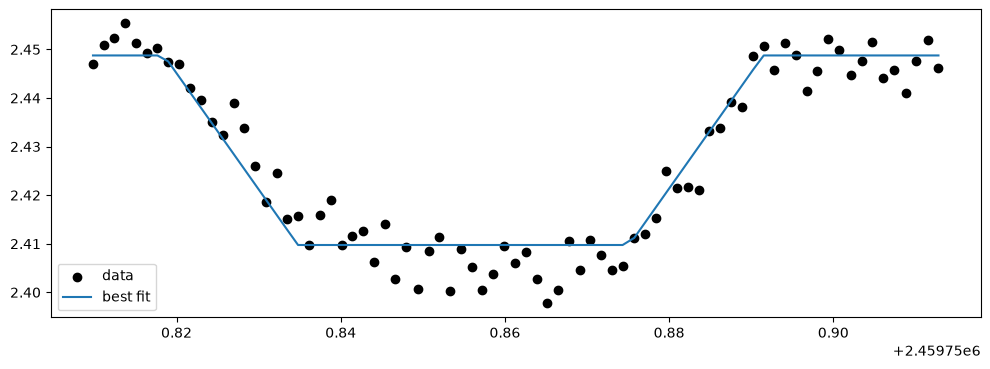

In [27]:
plt.figure(figsize=(12,4))
plt.scatter(t, detrended, label='data', color='k')
model = []
for i in t:
    model.append(transit_model(i,base,depth,fit.x[0], fit.x[1], fit.x[2]))
plt.plot(t, model, label='best fit')
plt.legend()
plt.show()

### Residuals and noise
After fitting a model to the transit, we want to subtract the model from the data to see if any weird patterns remain that may suggest a bad fit, and to caculate the noise in our data.

The box below plots data - model, and the standard deviation of the result, which is equal to the noise is printed into the plot title.

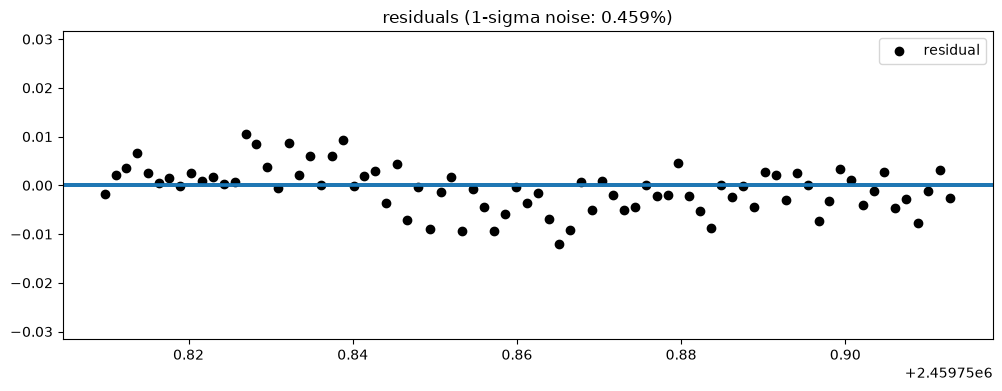

In [28]:
plt.figure(figsize=(12,4))
model = []
for i in t:
    model.append(transit_model(i,base,depth,fit.x[0], fit.x[1], fit.x[2]))
    plt.axhline(0)
plt.scatter(t, detrended-model, label='residual', color='k')
plt.legend()
plt.ylim(-np.max(detrended-model)*3,np.max(detrended-model)*3)
plt.title('residuals (1-sigma noise: ' +str(np.round(np.std(detrended-model)*100,3))+'%)')
plt.show()

### Analysis questions
Below are a few questions to answer based on the results. Feel free to create new cells below to do any math for the questions.
***
1. What is the radius of Wasp-2 b? Remember that the transit depth is given by $$\text{depth}=\frac{R_p^2}{R_s^2}$$ where $R_p$ is the planet radius and $R_s$ is the star's radius. The radius of the star Wasp-2 is 0.866$\times$ the radius of our Sun. Compare the radius of Wasp-2 b to the of Earth or Jupiter.
***
2. Given the noise in our lightcurve, what is the smallest planet we could detect? Stated differently, what size planet would give a transit depth equal to the noise? Again, compare the radius of the planet to the radius of Earth or Jupiter.
***
3. Imagine that instead of Wasp-2, we have a much smaller star that only has a radius of 0.12$\times$ the radius of the Sun. What is the smallest planet we could detect then if we had a lightcurve with the same noise? Again, compare the radius of the planet to the radius of Earth or Jupiter.